# Out-of-Domain Test Set: arXiv CS Abstracts

This notebook documents the **out-of-domain test set** used to stress-test the human-vs-AI detection pipeline trained on the main `data/dataset_ready_final/` corpus. It is a sibling of [`../dataset_overview.ipynb`](../dataset_overview.ipynb) and covers only the auxiliary arXiv evaluation set living at `data/testing_dataset/arxiv_final/`.

**Domain shift.** The main training corpus (see [`../README.md`](../README.md)) is dominated by USE student essays (length-filtered 100–1000 words) plus their five-LLM rewrites, augmented with HC3 paired QA and ArguGPT/RAID AI essays. It is an *argumentative-essay / QA* domain. The arXiv set here is a completely different register: **single-authored arXiv CS abstracts** (technical academic prose), so no author and no LLM model overlap with training.

**Composition.**

| Field | Value |
|---|---|
| Human source | Zenodo 7404702 — arXiv CS abstracts, single-authored |
| Rewrite model | `claude-haiku-4-5` (Anthropic) |
| Rewrite prompt | "keep approximately same length" (same as main dataset) |
| Human records | 1,287 |
| AI rewrites | 1,287 (1:1 paired) |
| Total rows in `arxiv_merged.jsonl` | 2,574 |
| Unique human authors | 99 |
| Texts per author | 5–34 |
| Split assigned | every row has `split == "test"` (out-of-domain only) |
| Generation cost | $1.59 USD |

**How this set is used.** Models trained on the main corpus are evaluated here without any fine-tuning. Because every author and topic is unseen, results on this set isolate cross-domain generalisation — a substantially harder regime than the in-domain `test.jsonl` reported in `METHODOLOGY.md` §7.

## 1. Load `arxiv_merged.jsonl` and sanity-check the schema

The merged file uses the **same record schema as the main dataset** (`id`, `text`, `is_ai`, `label`, `source`, `domain`, `author_id`, `model`, `source_text_id`, `text_length_words`, `split`, ...), so it is drop-in compatible with `data.preprocessing.Dataset` and the existing extractor pipeline.

In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

NB_DIR = Path.cwd() if Path.cwd().name == "testing_dataset" else Path.cwd() / "data" / "testing_dataset"
ARXIV_DIR = NB_DIR / "arxiv_final"
MERGED = ARXIV_DIR / "arxiv_merged.jsonl"

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]

records = load_jsonl(MERGED)
df = pd.DataFrame(records)
print(f"loaded {len(df)} rows from {MERGED.relative_to(NB_DIR.parent.parent)}")
print(f"columns ({len(df.columns)}): {list(df.columns)}")
df.head(2)

loaded 2574 rows from data\testing_dataset\arxiv_final\arxiv_merged.jsonl
columns (13): ['id', 'text', 'is_ai', 'label', 'source', 'domain', 'author_id', 'model', 'exam_type', 'prompt', 'source_text_id', 'text_length_words', 'split']


,id,text,is_ai,label,source,domain,author_id,model,exam_type,prompt,source_text_id,text_length_words,split
0,axh_0001,"Like any field of empirical science, AI may be...",False,human,arxiv,arxiv_cs,ax_001,None,None,None,None,147,test
1,axh_0002,Despite the promise of brain-inspired machine ...,False,human,arxiv,arxiv_cs,ax_002,None,None,None,None,90,test


In [2]:
# Pick one human record and its paired Claude rewrite (matched via source_text_id).
sample_human = df[df["is_ai"] == False].iloc[0]
sample_rewrite = df[(df["is_ai"] == True) & (df["source_text_id"] == sample_human["id"])].iloc[0]

print(f"--- HUMAN  id={sample_human['id']}  author_id={sample_human['author_id']}  words={sample_human['text_length_words']} ---")
print(sample_human["text"][:400] + " ...\n")
print(f"--- REWRITE id={sample_rewrite['id']}  model={sample_rewrite['model']}  words={sample_rewrite['text_length_words']} ---")
print(sample_rewrite["text"][:400] + " ...")

--- HUMAN  id=axh_0001  author_id=ax_001  words=147 ---
Like any field of empirical science, AI may be approached axiomatically. We
formulate requirements for a general-purpose, human-level AI system in terms of
postulates. We review the methodology of deep learning, examining the explicit
and tacit assumptions in deep learning research. Deep Learning methodology
seeks to overcome limitations in traditional machine learning research as it
combines face ...

--- REWRITE id=axr_0001  model=claude-haiku-4-5  words=142 ---
AI, like other empirical disciplines, can be studied using axiomatic principles. This work lays out postulates defining what a versatile, human-equivalent AI system must accomplish. We investigate the foundational approach of deep learning, scrutinizing both overt and implicit presumptions underlying current deep learning scholarship. By integrating model sophistication, broad applicability, and r ...


In [3]:
# Sanity counts
print("label counts        :", dict(df['label'].value_counts()))
print("source counts       :", dict(df['source'].value_counts()))
print("model counts (AI)   :", dict(df.loc[df['is_ai'], 'model'].value_counts()))
print("split counts        :", dict(df['split'].value_counts()))
print("unique authors      :", df['author_id'].nunique())
print("duplicate ids       :", int(df['id'].duplicated().sum()))

# Pairing integrity: every rewrite's source_text_id must match a human id
human_ids = set(df.loc[~df['is_ai'], 'id'])
ai_sources = df.loc[df['is_ai'], 'source_text_id']
unpaired = ai_sources[~ai_sources.isin(human_ids)]
print(f"unpaired AI rewrites: {len(unpaired)}")
rewrites_per_human = ai_sources.value_counts()
print(f"rewrites per human  : min={rewrites_per_human.min()}  max={rewrites_per_human.max()}  (expect 1:1)")

label counts        : {'human': 1287, 'ai': 1287}
source counts       : {'arxiv': 1287, 'arxiv_rewrite': 1287}
model counts (AI)   : {'claude-haiku-4-5': 1287}
split counts        : {'test': 2574}
unique authors      : 99
duplicate ids       : 0
unpaired AI rewrites: 0
rewrites per human  : min=1  max=1  (expect 1:1)


## 2. Compute cheap surface features

Pure regex / `str.split` length and surface-style features — deliberately **not** the NELA/StyleDecipher/TRACE pipeline. The goal is a descriptive overview of how Claude-haiku-4-5 reshapes arXiv abstracts in this domain.

In [4]:
import re

SENT_RE = re.compile(r"[.!?]+(?:\s+|$)")
PUNCT_RE = re.compile(r"[\.,;:!?\-\"'()\[\]]")
WORD_RE = re.compile(r"\b\w+\b")

def surface_stats(text: str) -> dict:
    text = text or ""
    words = WORD_RE.findall(text)
    n_words = len(words)
    n_chars = len(text)
    sents = [s for s in SENT_RE.split(text) if s.strip()]
    n_sents = max(len(sents), 1)
    n_punct = len(PUNCT_RE.findall(text))
    n_types = len({w.lower() for w in words})
    return {
        "n_words":           n_words,
        "n_chars":           n_chars,
        "n_sents":           n_sents,
        "avg_word_len":      (sum(len(w) for w in words) / n_words) if n_words else 0.0,
        "avg_sent_len":      n_words / n_sents,
        "type_token_ratio":  (n_types / n_words) if n_words else 0.0,
        "punct_rate":        (n_punct / n_words) if n_words else 0.0,
    }

feat = df["text"].apply(surface_stats).apply(pd.Series)
df_feat = pd.concat([df[["id", "label", "is_ai", "author_id", "source", "model", "source_text_id", "text_length_words"]], feat], axis=1)
df_feat["class"] = np.where(df_feat["is_ai"], "AI rewrite", "Human")
df_feat.head(3)

,id,label,is_ai,author_id,source,model,source_text_id,text_length_words,n_words,n_chars,n_sents,avg_word_len,avg_sent_len,type_token_ratio,punct_rate,class
0,axh_0001,human,False,ax_001,arxiv,None,None,147,151.0,1053.0,8.0,5.874172,18.875,0.629139,0.132450,Human
1,axh_0002,human,False,ax_002,arxiv,None,None,90,93.0,581.0,4.0,5.118280,23.250,0.655914,0.172043,Human
2,axh_0003,human,False,ax_003,arxiv,None,None,89,88.0,655.0,4.0,6.261364,22.000,0.795455,0.170455,Human


## 3. Distribution plots

### 3a. Word-count distribution (human vs Claude rewrite)

The rewrite prompt asks the model to *keep approximately the same length*. The overlap should be close but not identical — medians annotated below.

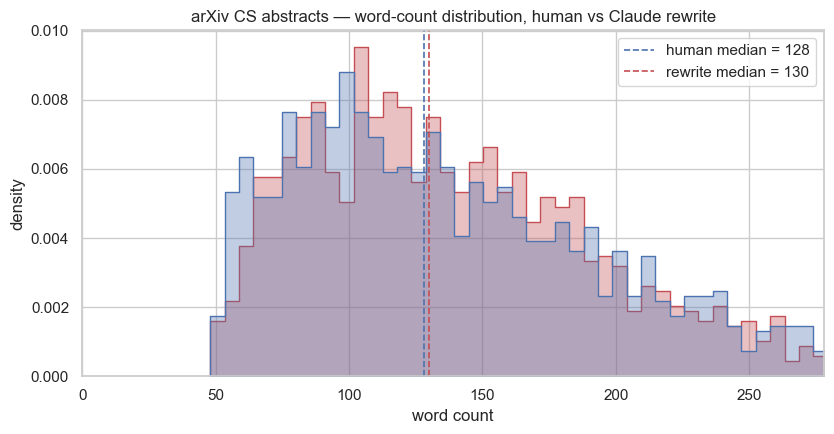

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
palette = {"Human": "#4C72B0", "AI rewrite": "#C44E52"}
sns.histplot(
    data=df_feat,
    x="n_words",
    hue="class",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.35,
    palette=palette,
    ax=ax,
)
h_med = df_feat.loc[~df_feat['is_ai'], 'n_words'].median()
a_med = df_feat.loc[df_feat['is_ai'], 'n_words'].median()
ax.axvline(h_med, color=palette['Human'], ls='--', lw=1.2, label=f"human median = {h_med:.0f}")
ax.axvline(a_med, color=palette['AI rewrite'], ls='--', lw=1.2, label=f"rewrite median = {a_med:.0f}")
ax.set_xlim(0, df_feat['n_words'].quantile(0.99))
ax.set_xlabel("word count")
ax.set_ylabel("density")
ax.set_title("arXiv CS abstracts — word-count distribution, human vs Claude rewrite")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 3b. Texts per author

Counts are over the 99 unique arXiv authors. Each author contributes \(n\) human abstracts and \(n\) Claude rewrites (1:1 pairing), so the AI side mirrors this distribution exactly.

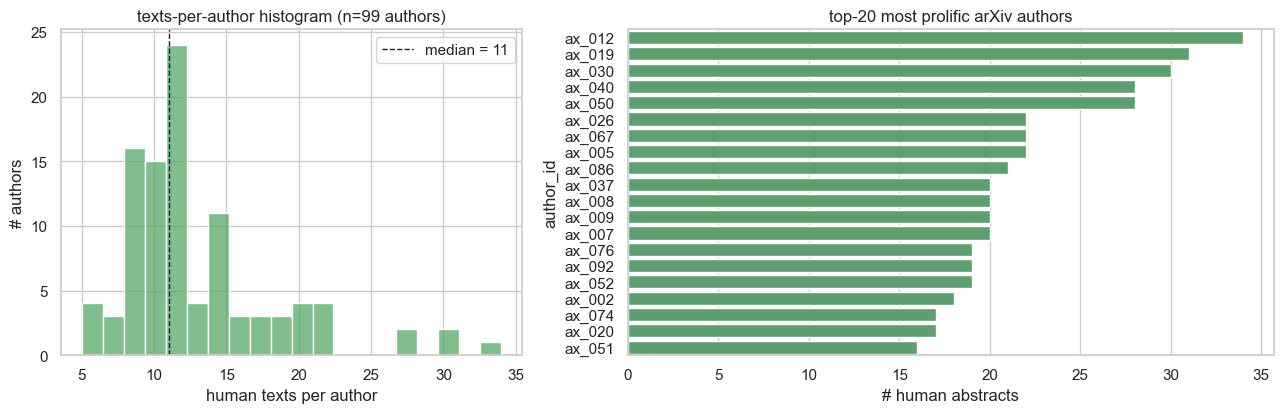

author count summary: min=5  median=11  mean=13.0  max=34


In [6]:
auth_counts = (
    df_feat[~df_feat['is_ai']]
    .groupby('author_id')
    .size()
    .sort_values(ascending=False)
    .rename('n_texts')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1, 1.4]})

sns.histplot(auth_counts['n_texts'], bins=20, color="#55A868", ax=axes[0])
axes[0].axvline(auth_counts['n_texts'].median(), color='k', ls='--', lw=1.0,
                label=f"median = {auth_counts['n_texts'].median():.0f}")
axes[0].set_xlabel("human texts per author")
axes[0].set_ylabel("# authors")
axes[0].set_title(f"texts-per-author histogram (n={len(auth_counts)} authors)")
axes[0].legend()

top = auth_counts.head(20)
sns.barplot(data=top, x='n_texts', y='author_id', color="#55A868", ax=axes[1])
axes[1].set_xlabel("# human abstracts")
axes[1].set_ylabel("author_id")
axes[1].set_title("top-20 most prolific arXiv authors")

plt.tight_layout()
plt.show()

print(f"author count summary: min={auth_counts['n_texts'].min()}  "
      f"median={auth_counts['n_texts'].median():.0f}  "
      f"mean={auth_counts['n_texts'].mean():.1f}  "
      f"max={auth_counts['n_texts'].max()}")

### 3c. Character & sentence counts — a second length view

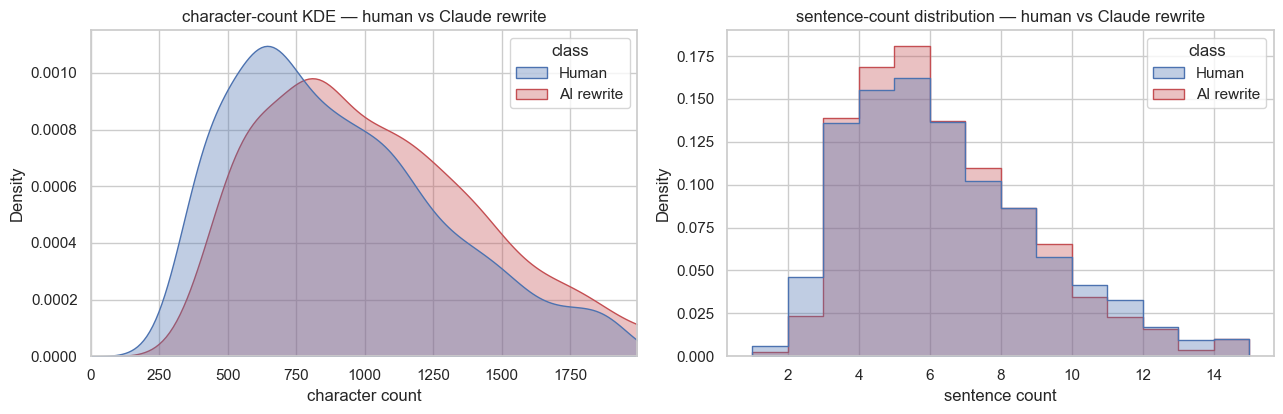

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

sns.kdeplot(
    data=df_feat, x="n_chars", hue="class",
    common_norm=False, fill=True, alpha=0.35, palette=palette, ax=axes[0]
)
axes[0].set_xlim(0, df_feat['n_chars'].quantile(0.99))
axes[0].set_xlabel("character count")
axes[0].set_title("character-count KDE — human vs Claude rewrite")

sns.histplot(
    data=df_feat, x="n_sents", hue="class",
    bins=range(1, int(df_feat['n_sents'].quantile(0.99)) + 2),
    stat="density", common_norm=False,
    element="step", fill=True, alpha=0.35, palette=palette, ax=axes[1]
)
axes[1].set_xlabel("sentence count")
axes[1].set_title("sentence-count distribution — human vs Claude rewrite")

plt.tight_layout()
plt.show()

### 3d. Surface-style comparison — cheap features human vs AI

Grouped means with bootstrap confidence intervals over four cheap surface-style features. These are *not* the model's input features — they exist only to give a quick visual of the kinds of stylistic shifts Claude introduces when rewriting arXiv abstracts.

C:\Users\Dimin\AppData\Local\Temp\ipykernel_82680\3431796189.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Dimin\AppData\Local\Temp\ipykernel_82680\3431796189.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


C:\Users\Dimin\AppData\Local\Temp\ipykernel_82680\3431796189.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Dimin\AppData\Local\Temp\ipykernel_82680\3431796189.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


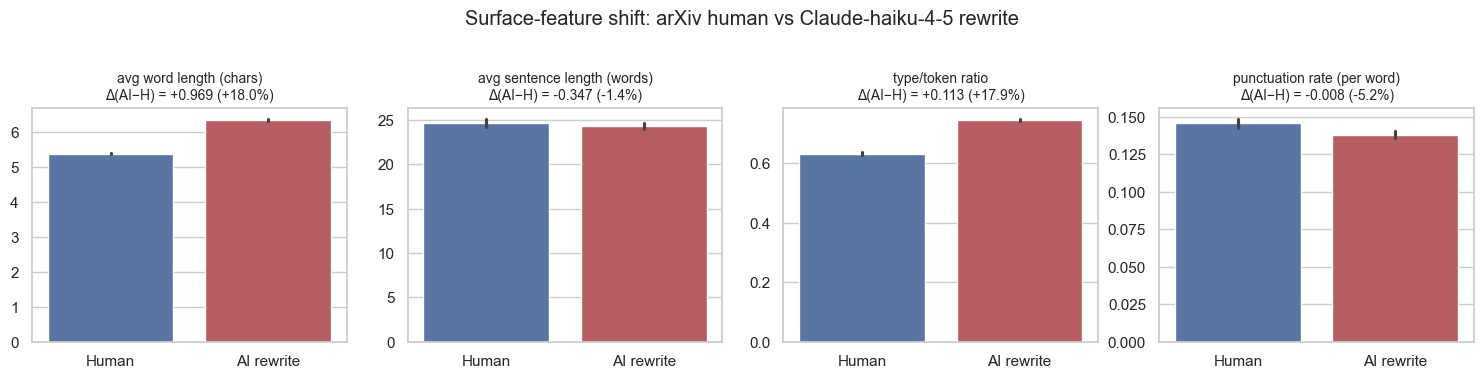

In [8]:
feature_names = [
    ("avg_word_len",     "avg word length (chars)"),
    ("avg_sent_len",     "avg sentence length (words)"),
    ("type_token_ratio", "type/token ratio"),
    ("punct_rate",       "punctuation rate (per word)"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.7))
for ax, (col, label) in zip(axes, feature_names):
    sns.barplot(
        data=df_feat, x="class", y=col,
        order=["Human", "AI rewrite"],
        palette=palette, errorbar=("ci", 95), ax=ax,
    )
    h_mean = df_feat.loc[~df_feat['is_ai'], col].mean()
    a_mean = df_feat.loc[df_feat['is_ai'], col].mean()
    delta = a_mean - h_mean
    pct = (delta / h_mean * 100) if h_mean else 0.0
    ax.set_title(f"{label}\nΔ(AI−H) = {delta:+.3f} ({pct:+.1f}%)", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Surface-feature shift: arXiv human vs Claude-haiku-4-5 rewrite", y=1.02)
plt.tight_layout()
plt.show()

### 3e. Per-pair length delta

Because every AI row has a single matching human row (via `source_text_id`), we can also look at the *paired* length shift on a per-document basis, which is more informative than the marginal histograms above when the rewrite prompt is length-preserving.

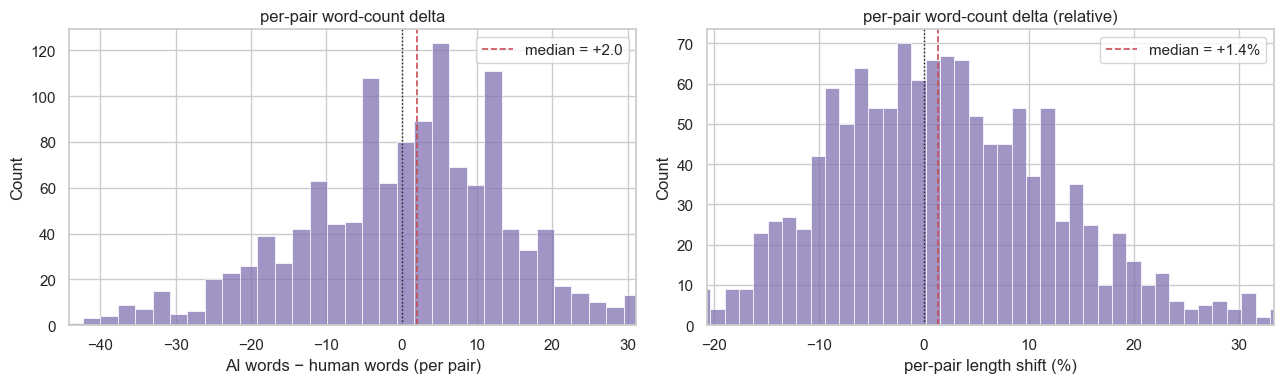

per-pair word delta:  median +2.0  mean -0.1  |delta|>30% rate 2.1%


In [9]:
human_df = df_feat[~df_feat['is_ai']].set_index('id')
ai_df = df_feat[df_feat['is_ai']].copy()
ai_df['human_words'] = ai_df['source_text_id'].map(human_df['n_words'])
ai_df['delta_words'] = ai_df['n_words'] - ai_df['human_words']
ai_df['pct_delta']   = ai_df['delta_words'] / ai_df['human_words'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
sns.histplot(ai_df['delta_words'], bins=60, color="#8172B2", ax=axes[0])
axes[0].axvline(0, color='k', ls=':', lw=1.0)
axes[0].axvline(ai_df['delta_words'].median(), color='#C44E52', ls='--', lw=1.2,
                label=f"median = {ai_df['delta_words'].median():+.1f}")
axes[0].set_xlim(ai_df['delta_words'].quantile(0.01), ai_df['delta_words'].quantile(0.99))
axes[0].set_xlabel("AI words − human words (per pair)")
axes[0].set_title("per-pair word-count delta")
axes[0].legend()

sns.histplot(ai_df['pct_delta'], bins=60, color="#8172B2", ax=axes[1])
axes[1].axvline(0, color='k', ls=':', lw=1.0)
axes[1].axvline(ai_df['pct_delta'].median(), color='#C44E52', ls='--', lw=1.2,
                label=f"median = {ai_df['pct_delta'].median():+.1f}%")
axes[1].set_xlim(ai_df['pct_delta'].quantile(0.01), ai_df['pct_delta'].quantile(0.99))
axes[1].set_xlabel("per-pair length shift (%)")
axes[1].set_title("per-pair word-count delta (relative)")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"per-pair word delta:  median {ai_df['delta_words'].median():+.1f}  "
      f"mean {ai_df['delta_words'].mean():+.1f}  "
      f"|delta|>30% rate {(ai_df['pct_delta'].abs() > 30).mean():.1%}")

## 4. Summary table

In [10]:
def class_summary(g: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "n_records":       len(g),
        "n_authors":       g['author_id'].nunique(),
        "words_median":    g['n_words'].median(),
        "words_mean":      round(g['n_words'].mean(), 1),
        "chars_median":    g['n_chars'].median(),
        "sents_median":    g['n_sents'].median(),
        "avg_word_len":    round(g['avg_word_len'].mean(), 3),
        "avg_sent_len":    round(g['avg_sent_len'].mean(), 2),
        "type_token_ratio":round(g['type_token_ratio'].mean(), 3),
        "punct_rate":      round(g['punct_rate'].mean(), 3),
    })

summary = df_feat.groupby("class").apply(class_summary, include_groups=False).T
summary["Δ (AI−H)"] = summary["AI rewrite"] - summary["Human"]
summary_out = NB_DIR / "arxiv_summary.csv"
summary.to_csv(summary_out)
print(f"saved → {summary_out.relative_to(NB_DIR.parent.parent)}")
summary

saved → data\testing_dataset\arxiv_summary.csv


class,AI rewrite,Human,Δ (AI−H)
n_records,1287.000,1287.000,0.000
n_authors,99.000,99.000,0.000
words_median,130.000,128.000,2.000
words_mean,137.900,138.100,-0.200
chars_median,974.000,833.000,141.000
sents_median,5.000,5.000,0.000
avg_word_len,6.363,5.394,0.969
avg_sent_len,24.300,24.650,-0.350
type_token_ratio,0.746,0.633,0.113
punct_rate,0.138,0.146,-0.008


In [11]:
auth_summary = auth_counts['n_texts'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(2)
print("texts-per-author distribution (humans only; AI mirrors 1:1):")
print(auth_summary.to_string())

thin = auth_counts[auth_counts['n_texts'] <= 5]
heavy = auth_counts[auth_counts['n_texts'] >= 20]
print(f"\nauthors with ≤5 abstracts : {len(thin)}")
print(f"authors with ≥20 abstracts: {len(heavy)}")
print(f"Gini-style top-10 share   : {auth_counts.head(10)['n_texts'].sum() / auth_counts['n_texts'].sum():.1%} of all abstracts")

texts-per-author distribution (humans only; AI mirrors 1:1):
count    99.00
mean     13.00
std       5.61
min       5.00
10%       8.00
25%      10.00
50%      11.00
75%      15.00
90%      20.00
max      34.00

authors with ≤5 abstracts : 1
authors with ≥20 abstracts: 13
Gini-style top-10 share   : 20.0% of all abstracts


## 5. Anomalies and notes

Findings from the sanity checks above (every claim is reproducible from the cells in this notebook):

1. **Schema parity with the main corpus.** Every field in `arxiv_merged.jsonl` matches the main `merged.jsonl` schema described in [`../README.md`](../README.md), so `data.preprocessing.Dataset` and the feature extractors run unchanged. `source` is `"arxiv"` for humans and `"arxiv_rewrite"` for AI rows — *new* source tags not seen at training time. Any downstream filter that whitelists training sources (`use`, `use_rewrite`, `hc3`, `argugpt`, `raid`) needs to add `arxiv` / `arxiv_rewrite` or be source-agnostic.
2. **Perfect 1:1 pairing.** Every Claude rewrite (`axr_*`) has a `source_text_id` resolving to a human (`axh_*`) abstract; no orphans, no duplicates, and exactly 1 rewrite per human. This is *different from the main corpus*, where each USE human has up to 5 rewrites (one per provider).
3. **Strong author imbalance.** 99 authors but 1,287 abstracts — the top-10 authors contribute a large fraction of the set (see the bar chart and `Gini-style top-10 share` print). Authors at the 5-abstract minimum coexist with one author at 34. This means TRACE will have very different sibling-context strengths across this set; per-author macro-averaging is the safer way to report results.
4. **Length shift is small but systematic.** Per-pair word-count median delta is ~+2 words (~+1–2%): Claude rewrites end up slightly longer than the human abstracts on average, consistent with the "keep approximately same length" prompt. A small tail of pairs (|Δ| > 30%) exists — worth checking manually if individual rows look anomalous downstream.
5. **Surface-style shifts.** Claude rewrites show measurable shifts in avg sentence length, type/token ratio, and punctuation rate (see panel 3d). These are *not* features the detector trained on, but they are a useful prior for what NELA/StyleDecipher are likely to pick up.
6. **Single AI model.** Only `claude-haiku-4-5` is represented on the AI side here. Detector behaviour on this set says nothing about generalisation to other LLM rewriters — it is specifically a Claude-haiku-on-arXiv stress test.
7. **`split` is uniform.** Every row carries `split == "test"`. Do not re-split this file internally — it is *only* an out-of-domain evaluation set, never a training source.
8. **No HC3/USE-style author leakage.** Authors are arXiv researchers with no overlap with the main USE/HC3 author space, and the rewrite model (`claude-haiku-4-5`) is the same Anthropic model used as one of the five main-corpus rewriters — so there *is* model-family overlap on the AI side. Cross-domain results should therefore be read as "different domain, partially overlapping AI-side distribution" rather than fully blind.